In [29]:
import math
import numpy as np
import matplotlib.pyplot as plt

In [9]:
"""
 This script uses the bisection method to approximate the root of a 
 scalar function.
"""

############################################# 
"""
Copyright (C) 2025  Adrianna M. Gillman

    This program is free software: you can redistribute it and/or modify
    it under the terms of the GNU General Public License as published by
    the Free Software Foundation, either version 3 of the License, or
    (at your option) any later version.

    This program is distributed in the hope that it will be useful,
    but WITHOUT ANY WARRANTY; without even the implied warranty of
    MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.  See the
    GNU General Public License for more details.

    You should have received a copy of the GNU General Public License
    along with this program.  If not, see <https://www.gnu.org/licenses/>.
"""
############################################# 

# import libraries
import numpy as np

def driver():

# use routines    
    f = lambda x: 2*x-1-np.sin(x)
    a = 0
    b = 2

    tol = 1e-8

    [astar,ier] = bisection(f,a,b,tol)
    print('the approximate root is',astar)
    print('the error message reads:',ier)
    print('f(astar) =', f(astar))


# define routines
def bisection(f,a,b,tol):
    
#    Inputs:
#     f,a,b       - function and endpoints of initial interval
#      tol  - bisection stops when interval length < tol

#    Returns:
#      astar - approximation of root
#      ier   - error message
#            - ier = 1 => Failed
#            - ier = 0 == success

#     first verify there is a root we can find in the interval 

    fa = f(a)
    fb = f(b);
    if (fa*fb>0):
       ier = 1
       astar = a
       return [astar, ier]

#   verify end points are not a root 
    if (fa == 0):
      astar = a
      ier =0
      return [astar, ier]

    if (fb ==0):
      astar = b
      ier = 0
      return [astar, ier]

    count = 0
    d = 0.5*(a+b)
    while (abs(d-a)> tol):
      fd = f(d)
      if (fd ==0):
        astar = d
        ier = 0
        return [astar, ier]
      if (fa*fd<0):
         b = d
      else: 
        a = d
        fa = fd
      d = 0.5*(a+b)
      count = count +1
#      print('abs(d-a) = ', abs(d-a))
      
    astar = d
    ier = 0
    print('count = ', count)
    return [astar, ier]
      
driver()               

count =  27
the approximate root is 0.8878622129559517
the error message reads: 0
f(astar) = 1.8960828462866175e-09


[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


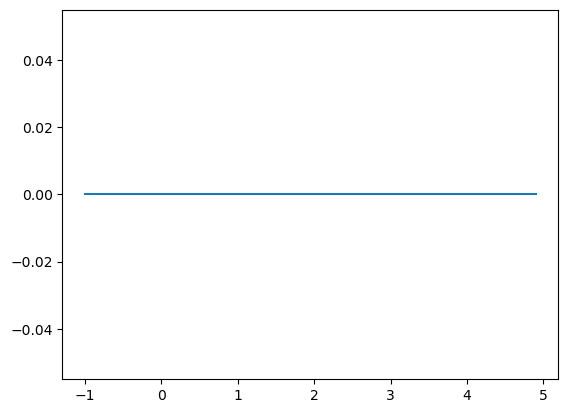

In [58]:
def problem_3():
    x_list = np.arange(-1, 5, .1)
    results = []
    results_np = []
    results_diff = []
    
    for x in x_list:
        y = math.e**x
        result = y - 1
        resultnp = np.e**x - 1
        results_np.append(resultnp)
        results.append(result)
        results_diff.append(results[-1] - results_np[-1])

    plt.plot(x_list, results_diff)
    return results_diff

print(problem_3())

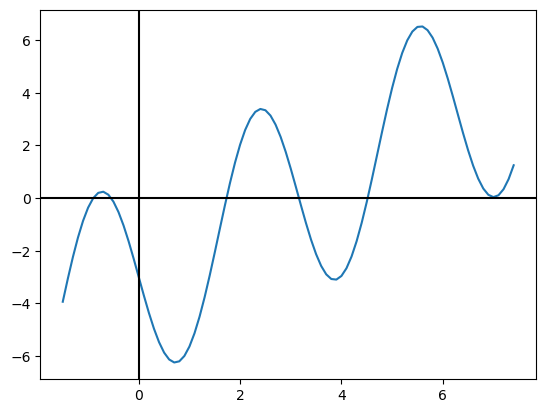

The questionable point near x=7 returns the value: 0.03757057722051815.
0.03757057722051815


In [93]:
def problem_6():
    x_range = np.arange(-1.5,7.5,.1)
    y = lambda x: x-4*np.sin(2*x)-3
    results = []
    check = None

    for x in x_range:
        results.append(y(x))
        #print(x)
        if x - 7.0 < 0.5*10**(-10): #check that error if that x = 7.0 point is a root or not. Bound given by 
            check = y(x)

    plt.plot(x_range, results)
    plt.axhline(0, color = 'black')
    plt.axvline(0, color = 'black')
    plt.show()
    print(f'The questionable point near x=7 returns the value: {check}.')
    return check

print(problem_6())

In [85]:
"""
 This script explores the use of the fixed point method.  
 Two functions are considered that have different properties.
 I like to use this code before I talk about convergence analysis
 for the fixed point method as motivation.
"""

############################################# 
"""
Copyright (C) 2025  Adrianna M. Gillman

    This program is free software: you can redistribute it and/or modify
    it under the terms of the GNU General Public License as published by
    the Free Software Foundation, either version 3 of the License, or
    (at your option) any later version.

    This program is distributed in the hope that it will be useful,
    but WITHOUT ANY WARRANTY; without even the implied warranty of
    MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.  See the
    GNU General Public License for more details.

    You should have received a copy of the GNU General Public License
    along with this program.  If not, see <https://www.gnu.org/licenses/>.
"""
############################################# 

# import libraries
import numpy as np
    
def driver():

# test functions 
    f1 = lambda x: -np.sin(2*x)+(5*x/4)-3/4

    Nmax = 100
    tol = (1/2)*(10**(-10)) #adjusted to have 10 digits of precision?

# test f1 '''
    x0 = [-3, -0.5, 1.7, 3.2, 4.5]
    for x in x0:
        [xstar,ier] = fixedpt(f1,x,tol,Nmax)
        print('the approximate fixed point is:',xstar)
        print('f1(xstar):',f1(xstar))
        print('Error message reads:',ier)


# define routines
def fixedpt(f,x0,tol,Nmax):

    ''' x0 = initial guess''' 
    ''' Nmax = max number of iterations'''
    ''' tol = stopping tolerance'''

    count = 0
    while (count <Nmax):
       count = count +1
       x1 = f(x0)
       if (abs(x1-x0) <tol):
          xstar = x1
          ier = 0
          return [xstar,ier]
       x0 = x1

    xstar = x1
    ier = 1
    return [xstar, ier]
    

driver()

the approximate fixed point is: -32087099695.773247
f1(xstar): -40108874619.73963
Error message reads: 1
the approximate fixed point is: -0.5444424006660251
f1(xstar): -0.5444424006759575
Error message reads: 0
the approximate fixed point is: -0.5444424007000309
f1(xstar): -0.5444424006869433
Error message reads: 0
the approximate fixed point is: 3.161826486570247
f1(xstar): 3.1618264865382506
Error message reads: 0
the approximate fixed point is: 3.161826486571215
f1(xstar): 3.161826486537526
Error message reads: 0


In [81]:
def func(x):
    y = np.e**x
    return y-1

def poly(x):
    f1 = lambda x: x + x**(2)/2
    #real = 1
    #relative_err = (f1(x)-real)/real
    return f1(x)

poly(9.999999995000000*10**(-10))

#func(9.999999995000000*10**(-10))

#func(10*(-9))

1e-09